In [2]:
import os
import pyarrow.parquet as pq
import pyarrow.compute as pc
from urllib.parse import urlparse
from collections import defaultdict

base_dirs = [
    r"G:\Thesis\0000_embeddings_cleaned",
    r"G:\Thesis\0001_embeddings_cleaned",
    r"G:\Thesis\0002_embeddings_cleaned",
    r"G:\Thesis\0003_embeddings_cleaned"
]

domain_counts = defaultdict(int)

def extract_domain(url):
    try:
        parsed = urlparse(url)
        return parsed.netloc.lower()
    except Exception:
        return None

for base_dir in base_dirs:
    print(f"\nProcessing directory: {base_dir}")

    for file in os.listdir(base_dir):
        if not file.endswith(".parquet"):
            continue

        file_path = os.path.join(base_dir, file)
        print(f"  File: {file}")

        parquet_file = pq.ParquetFile(file_path)

        for rg_idx in range(parquet_file.num_row_groups):

            # Detect embedding column dynamically
            schema_names = parquet_file.schema.names
            embedding_col = "embeddings_result"

            try:
                # -------- FAST VECTORISED PATH --------
                table = parquet_file.read_row_group(
                    rg_idx,
                    columns=["url", embedding_col]
                )

                mask = pc.is_valid(table[embedding_col])
                filtered_urls = table["url"].filter(mask)

                for url in filtered_urls.to_pylist():
                    domain = extract_domain(url)
                    if domain:
                        domain_counts[domain] += 1

            except Exception as e:
                # -------- FALLBACK SAFE LOOP --------
                print(f"    Falling back to slow path (row group {rg_idx})")

                table = parquet_file.read_row_group(
                    rg_idx,
                    columns=["url", embedding_col]
                )

                urls = table.column("url")
                embeddings = table.column(embedding_col)

                for i in range(len(table)):
                    if embeddings[i].as_py() is not None:
                        url = urls[i].as_py()
                        domain = extract_domain(url)
                        if domain:
                            domain_counts[domain] += 1

print("\nTop 20 domains:")
for domain, count in sorted(domain_counts.items(), key=lambda x: -x[1])[:20]:
    print(f"{domain}: {count}")



Processing directory: G:\Thesis\0000_embeddings_cleaned
  File: part-00000.parquet
  File: part-00001.parquet
  File: part-00002.parquet
  File: part-00003.parquet
  File: part-00004.parquet
  File: part-00005.parquet
  File: part-00006.parquet
  File: part-00007.parquet
  File: part-00008.parquet

Processing directory: G:\Thesis\0001_embeddings_cleaned
  File: part-00000.parquet
  File: part-00001.parquet
  File: part-00002.parquet
  File: part-00003.parquet
  File: part-00004.parquet
  File: part-00005.parquet
  File: part-00006.parquet
  File: part-00007.parquet
  File: part-00008.parquet

Processing directory: G:\Thesis\0002_embeddings_cleaned
  File: part-00000.parquet
  File: part-00001.parquet
  File: part-00002.parquet
  File: part-00003.parquet
  File: part-00004.parquet
  File: part-00005.parquet
  File: part-00006.parquet
  File: part-00007.parquet
  File: part-00008.parquet

Processing directory: G:\Thesis\0003_embeddings_cleaned
  File: part-00000.parquet
  File: part-000

In [3]:
import json
sorted_domains = dict(
    sorted(domain_counts.items(), key=lambda x: -x[1])
)

output_path = r"domain_counts_embeddings_present.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(sorted_domains, f, indent=2)

print(f"\nSaved sorted domain counts to {output_path}")


Saved sorted domain counts to domain_counts_embeddings_present.json


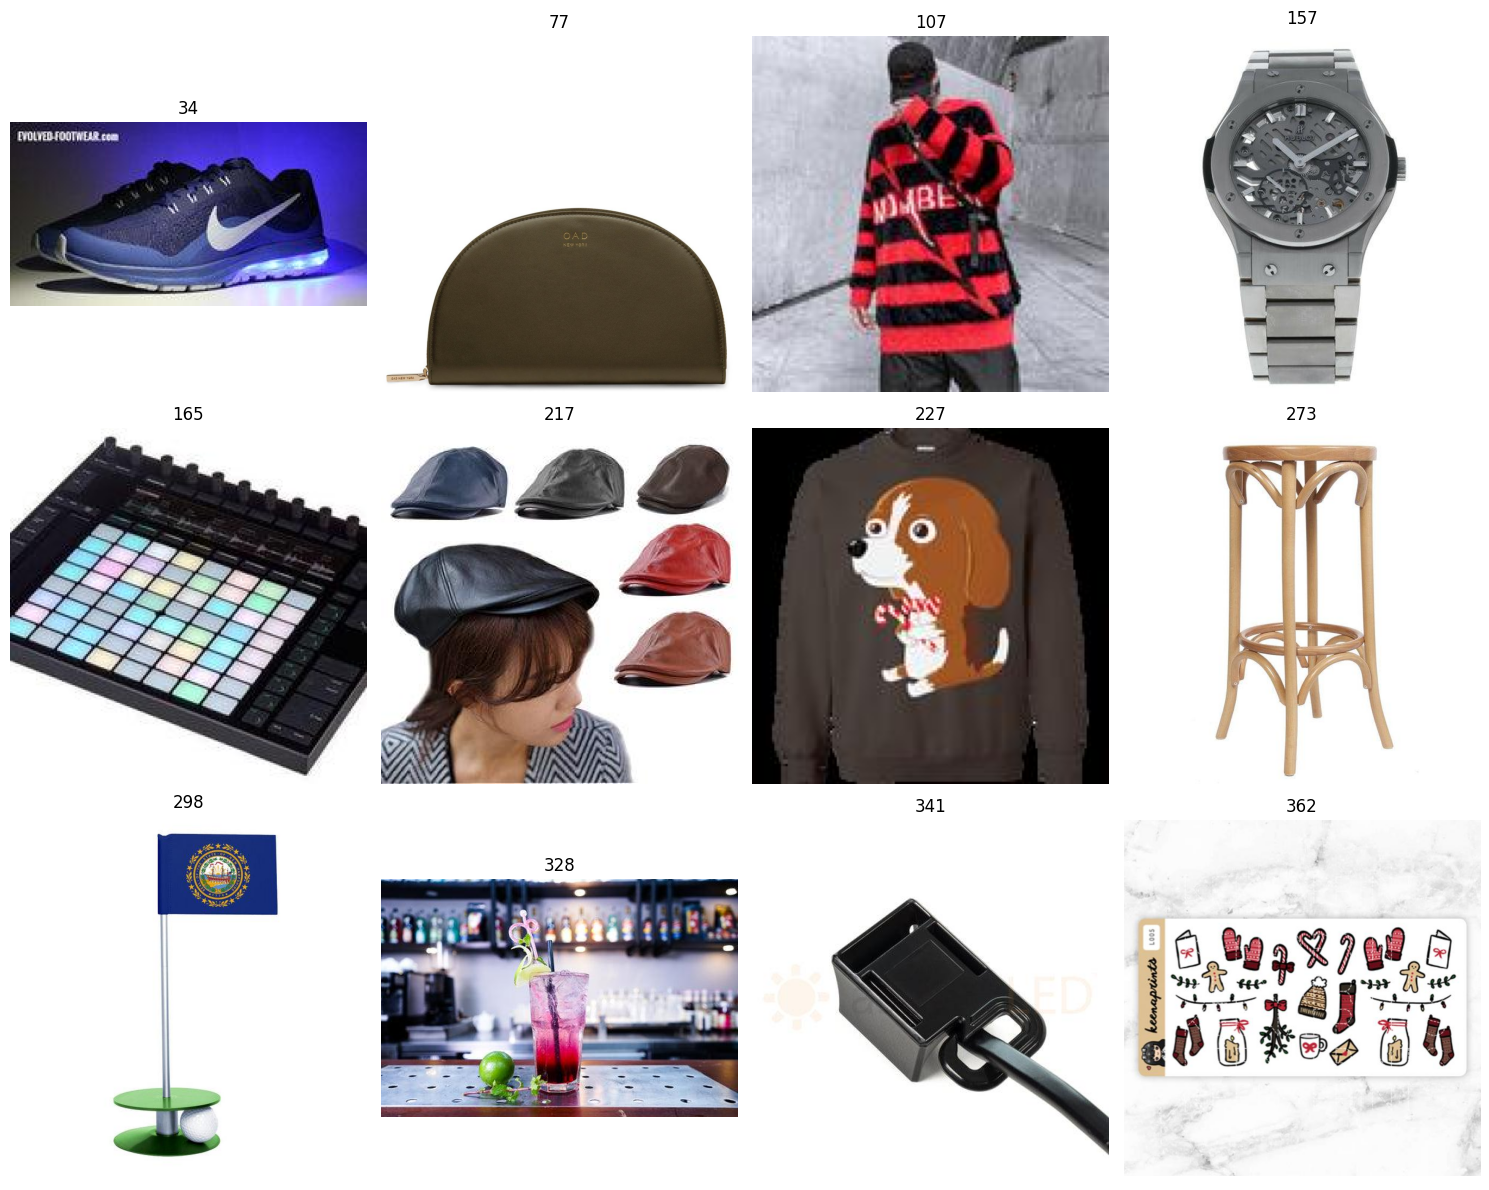

In [8]:
import os
import pyarrow.parquet as pq
import pyarrow.compute as pc
from urllib.parse import urlparse
from PIL import Image
import matplotlib.pyplot as plt

target_domain = "cdn.shopify.com"
max_images = 12

base_dirs = [
    r"G:\Thesis\0000_embeddings_cleaned",
    r"G:\Thesis\0001_embeddings_cleaned",
    r"G:\Thesis\0002_embeddings_cleaned",
    r"G:\Thesis\0003_embeddings_cleaned"
]

collected_indices = []

def extract_domain(url):
    try:
        return urlparse(url).netloc.lower()
    except:
        return None

for base_dir in base_dirs:
    image_dir = base_dir.replace("_embeddings_cleaned", "_images")

    for file in os.listdir(base_dir):
        if not file.endswith(".parquet"):
            continue

        file_path = os.path.join(base_dir, file)
        parquet_file = pq.ParquetFile(file_path)

        schema_names = parquet_file.schema.names
        embedding_col = "embeddings_result"

        for rg_idx in range(parquet_file.num_row_groups):

            table = parquet_file.read_row_group(
                rg_idx,
                columns=["original_image_index", "url", embedding_col]
            )

            # Filter embeddings != null
            mask = pc.is_valid(table[embedding_col])
            filtered = table.filter(mask)

            urls = filtered["url"].to_pylist()
            indices = filtered["original_image_index"].to_pylist()

            for url, idx in zip(urls, indices):
                if extract_domain(url) == target_domain:
                    collected_indices.append((image_dir, idx))

                    if len(collected_indices) >= max_images:
                        break

            if len(collected_indices) >= max_images:
                break

        if len(collected_indices) >= max_images:
            break

    if len(collected_indices) >= max_images:
        break

# ✅ Display images
cols = 4
rows = (len(collected_indices) + cols - 1) // cols

plt.figure(figsize=(15, 4 * rows))

for i, (img_dir, idx) in enumerate(collected_indices):
    img_path = os.path.join(img_dir, f"{idx}.jpg")

    if os.path.exists(img_path):
        img = Image.open(img_path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"{idx}")
        plt.axis("off")

plt.tight_layout()
plt.show()


#### Derive Train/Test/Split

In [1]:
import os
import json
import random
import hashlib
from collections import defaultdict
from urllib.parse import urlparse

import pyarrow.parquet as pq
import pyarrow.compute as pc

# ============================================================
# CONFIG
# ============================================================

target_domains = [
    "cdn.shopify.com",
    "i.pinimg.com",
    "i.ebayimg.com"
]

images_per_domain = 100_000
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

random_seed = 42
stratify_by_shard = True   # Balance across parquet shards

output_json = "domain_splits_stratified.json"

base_dirs = [
    r"G:\Thesis\0000_embeddings_cleaned",
    r"G:\Thesis\0001_embeddings_cleaned",
    r"G:\Thesis\0002_embeddings_cleaned",
    r"G:\Thesis\0003_embeddings_cleaned"
]

# ============================================================
# SET SEED
# ============================================================

random.seed(random_seed)

# ============================================================
# HELPERS
# ============================================================

def extract_domain(url):
    try:
        return urlparse(url).netloc.lower()
    except:
        return None

def hash_path(path):
    """For dedup protection."""
    return hashlib.md5(path.encode()).hexdigest()

def split_samples(samples):
    random.shuffle(samples)
    n = len(samples)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train = samples[:n_train]
    val = samples[n_train:n_train + n_val]
    test = samples[n_train + n_val:]

    return train, val, test

# ============================================================
# COLLECTION
# ============================================================

domain_to_samples = {d: [] for d in target_domains}
domain_shard_tracker = defaultdict(lambda: defaultdict(list))
global_seen_hashes = set()

for base_dir in base_dirs:

    image_dir = base_dir.replace("_embeddings_cleaned", "_images")

    for file in os.listdir(base_dir):

        if not file.endswith(".parquet"):
            continue

        parquet_path = os.path.join(base_dir, file)
        parquet_file = pq.ParquetFile(parquet_path)
        embedding_col = "embeddings_result"

        shard_id = file

        for rg_idx in range(parquet_file.num_row_groups):
            print(f"Reading {file} row group {rg_idx}")

            table = parquet_file.read_row_group(
                rg_idx,
                columns=["original_image_index", "url", embedding_col]
            )

            # mask = pc.is_valid(table[embedding_col])
            # filtered = table.filter(mask)

            urls = table["url"].to_pylist()
            indices = table["original_image_index"].to_pylist()

            for url, idx in zip(urls, indices):

                domain = extract_domain(url)
                if domain not in domain_to_samples:
                    continue

                if len(domain_to_samples[domain]) >= images_per_domain:
                    continue

                img_path = os.path.join(image_dir, f"{idx}.jpg")

                if not os.path.exists(img_path):
                    continue

                path_hash = hash_path(img_path)

                # Dedup across entire dataset
                if path_hash in global_seen_hashes:
                    continue

                global_seen_hashes.add(path_hash)

                if stratify_by_shard:
                    domain_shard_tracker[domain][shard_id].append(img_path)
                else:
                    domain_to_samples[domain].append(img_path)

        # Early exit if full
        if all(len(v) >= images_per_domain for v in domain_to_samples.values()):
            break

    if all(len(v) >= images_per_domain for v in domain_to_samples.values()):
        break

# ============================================================
# SHARD BALANCING
# ============================================================

if stratify_by_shard:

    for domain in target_domains:
        shard_dict = domain_shard_tracker[domain]

        all_samples = []
        shards = list(shard_dict.keys())
        per_shard_quota = max(1, images_per_domain // max(1, len(shards)))

        for shard in shards:
            shard_samples = shard_dict[shard]
            random.shuffle(shard_samples)
            all_samples.extend(shard_samples[:per_shard_quota])

        # If under quota, fill randomly
        if len(all_samples) < images_per_domain:
            remaining = images_per_domain - len(all_samples)
            flattened = [p for s in shard_dict.values() for p in s]
            random.shuffle(flattened)
            for p in flattened:
                if p not in all_samples:
                    all_samples.append(p)
                if len(all_samples) >= images_per_domain:
                    break

        domain_to_samples[domain] = all_samples[:images_per_domain]

# ============================================================
# CREATE SPLITS
# ============================================================

splits = {"train": [], "val": [], "test": []}
split_integrity_set = set()

for label, domain in enumerate(target_domains):

    samples = domain_to_samples[domain]

    print(f"{domain}: {len(samples)} collected")

    train_s, val_s, test_s = split_samples(samples)

    for split_name, subset in zip(
        ["train", "val", "test"],
        [train_s, val_s, test_s]
    ):
        for p in subset:

            if p in split_integrity_set:
                raise RuntimeError(f"Data leakage detected: {p}")

            split_integrity_set.add(p)

            splits[split_name].append({
                "image": p,
                "label": label
            })

# ============================================================
# SAVE
# ============================================================

with open(output_json, "w", encoding="utf-8") as f:
    json.dump(splits, f, indent=2)

print("\nSplit summary:")
for split in ["train", "val", "test"]:
    print(f"{split}: {len(splits[split])}")

print(f"\nSaved to {output_json}")


Reading part-00000.parquet row group 0
Reading part-00000.parquet row group 1
Reading part-00000.parquet row group 2
Reading part-00000.parquet row group 3
Reading part-00000.parquet row group 4
Reading part-00000.parquet row group 5
Reading part-00000.parquet row group 6
Reading part-00000.parquet row group 7
Reading part-00000.parquet row group 8
Reading part-00000.parquet row group 9
Reading part-00001.parquet row group 0
Reading part-00001.parquet row group 1
Reading part-00001.parquet row group 2
Reading part-00001.parquet row group 3
Reading part-00001.parquet row group 4
Reading part-00001.parquet row group 5
Reading part-00001.parquet row group 6
Reading part-00001.parquet row group 7
Reading part-00001.parquet row group 8
Reading part-00001.parquet row group 9
Reading part-00002.parquet row group 0
Reading part-00002.parquet row group 1
Reading part-00002.parquet row group 2
Reading part-00002.parquet row group 3
Reading part-00002.parquet row group 4
Reading part-00002.parque